# Ejemplo de Regresión Lineal: Satisfacción vs. PIB

En este Notebook aprenderás a:
1. Descargar y preparar datos.
2. Visualizarlos.
3. Entrenar un modelo de regresión lineal.
4. Realizar predicciones.
5. Resolver ejercicios que fomentan el pensamiento crítico.

In [2]:
## 1. Importación de Librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

numpy, pandas: manejo de datos numéricos y tabulares.

matplotlib: visualización.

sklearn.linear_model: contiene la clase LinearRegression.

In [3]:
data_url = "https://github.com/ageron/data/raw/main/lifesat/lifesat.csv"
df = pd.read_csv(data_url)

X = df["GDP per capita (USD)"].values.reshape(-1, 1)
y = df["Life satisfaction"].values

read_csv: carga el archivo CSV con datos.

X: PIB per cápita.

y: nivel de satisfacción con la vida.

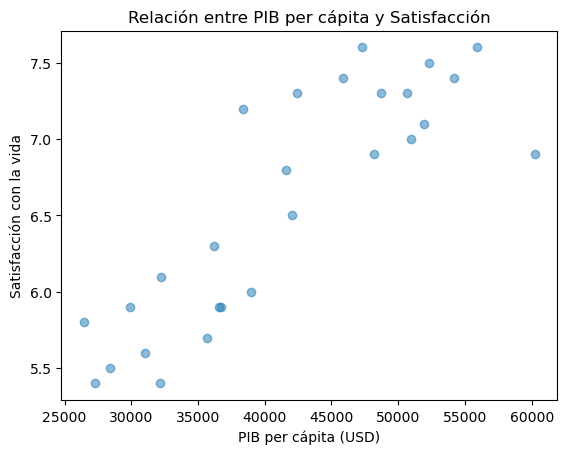

In [5]:
plt.scatter(X, y, alpha=0.5)
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Satisfacción con la vida")
plt.title("Relación entre PIB per cápita y Satisfacción")
plt.show()


Graficamos puntos (PIB vs. Satisfacción).

Observa la tendencia general: a mayor PIB, suele haber mayor satisfacción.

In [7]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

Nota: Crea una instancia de LinearRegression.

fit(X, y): ajusta el modelo para “aprender” la relación PIB-Satisfacción.

In [8]:
X_nuevo = [[35000]]  # PIB per cápita de prueba
y_pred = model.predict(X_nuevo)
print(f"Predicción de satisfacción para PIB = {X_nuevo[0][0]}: {y_pred[0]:.2f}")

Predicción de satisfacción para PIB = 35000: 6.12


predict(X_nuevo): obtiene la satisfacción estimada para un PIB de 35,000 USD.

## Ejercicios Propuestos

### 1. Cambiar el modelo
Sustituye `LinearRegression` por otros modelos, por ejemplo:

- `KNeighborsRegressor` (de `sklearn.neighbors`)
- `DecisionTreeRegressor` (de `sklearn.tree`)

**Tarea**: Entrena y evalúa cada uno.  
**Objetivo**: Compara los resultados obtenidos y comenta las diferencias observadas.

---

### 2. Añadir outliers
Inserta manualmente puntos con:

- PIB per cápita **muy alto** o **muy bajo**
- Valores de satisfacción **extremos**

**Tarea**: Observa cómo se modifica la línea (o curva) de predicción.  
**Reflexión**: ¿Qué modelo es más sensible a los outliers?

---

### 3. Comparación de rendimiento
Utiliza métricas de evaluación como:

- `r2_score`
- `mean_squared_error`

**Tarea**: Evalúa todos los modelos con los mismos datos.  
**Objetivo**: Determina cuál funciona mejor y justifica por qué.

---

### 4. Visualizar predicciones y errores

- Representa la **recta o curva de predicción** sobre los datos reales.
- Calcula los errores:  
  ```python
  errores = y_real - y_predicho


**Resultados sin outliers**
Lineal: MSE = 0.1539, R2 = 0.7273
KNN: MSE = 0.0849, R2 = 0.8496
Árbol: MSE = 0.0450, R2 = 0.9203


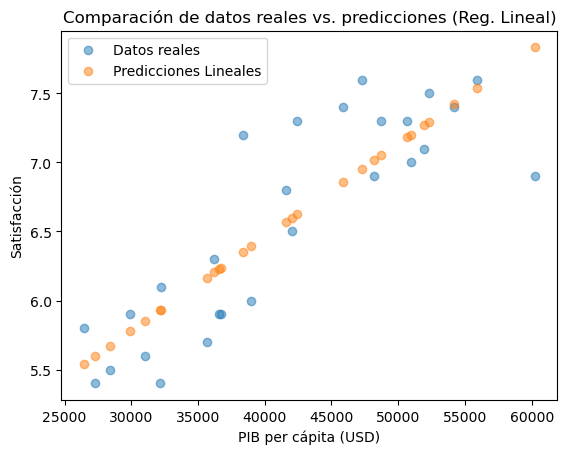

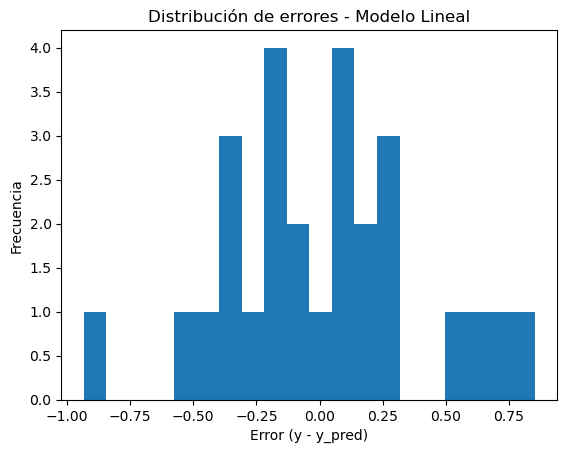


**Resultados con outliers**
Lineal: MSE = 1.4383, R2 = 0.0035
KNN: MSE = 0.9389, R2 = 0.3495
Árbol: MSE = 0.0624, R2 = 0.9568

ANÁLISIS:
- Sin outliers, la regresión lineal tiende a ajustarse de forma estable. El KNN
  puede adaptarse bien en zonas densas y el árbol de decisión modela bien no linealidades.
- Con outliers, se aprecia cómo la MSE aumenta, especialmente en modelos sensibles
  como la regresión lineal, que se ve más afectada. El árbol de decisión y KNN pueden
  resistir mejor ciertos outliers, dependiendo de su configuración.


In [10]:
# Script con Resultados y Análisis de Ejercicios

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Carga de datos
data_url = "https://github.com/ageron/data/raw/main/lifesat/lifesat.csv"
df = pd.read_csv(data_url)

X = df["GDP per capita (USD)"].values.reshape(-1, 1)
y = df["Life satisfaction"].values

# 2. Definición de modelos
models = {
    "Lineal": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=3),
    "Árbol": DecisionTreeRegressor(max_depth=3, random_state=42),
}

def evaluar_modelos(X_data, y_data, modelos):
    """Entrena cada modelo, evalúa MSE y R2, y devuelve resultados en un dict."""
    resultados = {}
    for nombre, modelo in modelos.items():
        modelo.fit(X_data, y_data)
        y_pred = modelo.predict(X_data)
        mse = mean_squared_error(y_data, y_pred)
        r2 = r2_score(y_data, y_pred)
        resultados[nombre] = (mse, r2)
    return resultados

# 3. Evaluación inicial (sin outliers)
resultados_inicial = evaluar_modelos(X, y, models)
print("**Resultados sin outliers**")
for nombre, (mse, r2) in resultados_inicial.items():
    print(f"{nombre}: MSE = {mse:.4f}, R2 = {r2:.4f}")

# 4. Visualización de predicciones y errores (ejemplo con modelo lineal)
modelo_lineal = models["Lineal"]
y_pred_lineal = modelo_lineal.predict(X)
errores_lineal = y - y_pred_lineal

plt.figure()
plt.scatter(X, y, alpha=0.5, label="Datos reales")
plt.scatter(X, y_pred_lineal, alpha=0.5, label="Predicciones Lineales")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Satisfacción")
plt.title("Comparación de datos reales vs. predicciones (Reg. Lineal)")
plt.legend()
plt.show()

plt.figure()
plt.hist(errores_lineal, bins=20)
plt.xlabel("Error (y - y_pred)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores - Modelo Lineal")
plt.show()

# 5. Introducción de outliers artificiales
#   (dos países hipotéticos con PIB muy alto y satisfacción extrema)
X_outliers = np.vstack([X, [[150000], [200000]]])
y_outliers = np.hstack([y, [2, 9]])  # Uno con satisfacción muy baja y otro muy alta

# 6. Re-evaluación con outliers
resultados_con_outliers = evaluar_modelos(X_outliers, y_outliers, models)
print("\n**Resultados con outliers**")
for nombre, (mse, r2) in resultados_con_outliers.items():
    print(f"{nombre}: MSE = {mse:.4f}, R2 = {r2:.4f}")

# 7. Pequeño análisis final
print("\nANÁLISIS:")
print("- Sin outliers, la regresión lineal tiende a ajustarse de forma estable. El KNN")
print("  puede adaptarse bien en zonas densas y el árbol de decisión modela bien no linealidades.")
print("- Con outliers, se aprecia cómo la MSE aumenta, especialmente en modelos sensibles")
print("  como la regresión lineal, que se ve más afectada. El árbol de decisión y KNN pueden")
print("  resistir mejor ciertos outliers, dependiendo de su configuración.")
